# Multi-Class SVM Strategies: 2D Fisher Iris Data
Import libraries and data set.

In [1]:
# imports

import pandas as pd
import numpy as np
from sklearn.svm import SVC

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OutputCodeClassifier
from sklearn.inspection import DecisionBoundaryDisplay

['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


[[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]
 [5.4 1.7]
 [4.6 1.4]
 [5.  1.5]
 [4.4 1.4]
 [4.9 1.5]
 [5.4 1.5]
 [4.8 1.6]
 [4.8 1.4]
 [4.3 1.1]
 [5.8 1.2]
 [5.7 1.5]
 [5.4 1.3]
 [5.1 1.4]
 [5.7 1.7]
 [5.1 1.5]
 [5.4 1.7]
 [5.1 1.5]
 [4.6 1. ]
 [5.1 1.7]
 [4.8 1.9]
 [5.  1.6]
 [5.  1.6]
 [5.2 1.5]
 [5.2 1.4]
 [4.7 1.6]
 [4.8 1.6]
 [5.4 1.5]
 [5.2 1.5]
 [5.5 1.4]
 [4.9 1.5]
 [5.  1.2]
 [5.5 1.3]
 [4.9 1.4]
 [4.4 1.3]
 [5.1 1.5]
 [5.  1.3]
 [4.5 1.3]
 [4.4 1.3]
 [5.  1.6]
 [5.1 1.9]
 [4.8 1.4]
 [5.1 1.6]
 [4.6 1.4]
 [5.3 1.5]
 [5.  1.4]
 [7.  4.7]
 [6.4 4.5]
 [6.9 4.9]
 [5.5 4. ]
 [6.5 4.6]
 [5.7 4.5]
 [6.3 4.7]
 [4.9 3.3]
 [6.6 4.6]
 [5.2 3.9]
 [5.  3.5]
 [5.9 4.2]
 [6.  4. ]
 [6.1 4.7]
 [5.6 3.6]
 [6.7 4.4]
 [5.6 4.5]
 [5.8 4.1]
 [6.2 4.5]
 [5.6 3.9]
 [5.9 4.8]
 [6.1 4. ]
 [6.3 4.9]
 [6.1 4.7]
 [6.4 4.3]
 [6.6 4.4]
 [6.8 4.8]
 [6.7 5. ]
 [6.  4.5]
 [5.7 3.5]
 [5.5 3.8]
 [5.5 3.7]
 [5.8 3.9]
 [6.  5.1]
 [5.4 4.5]
 [6.  4.5]
 [6.7 4.7]
 [6.3 4.4]
 [5.6 4.1]
 [5.5 4. ]
 [5.5 4.4]

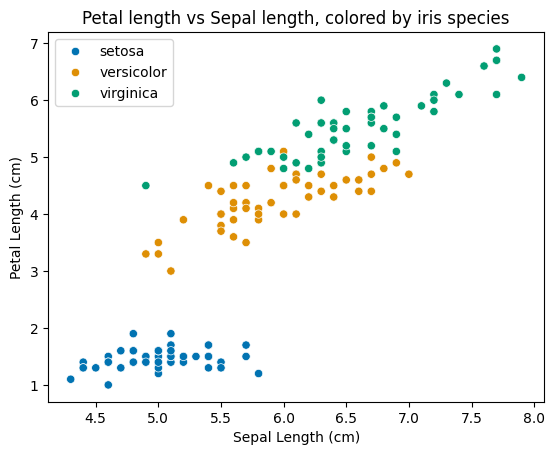

In [2]:
# viewing the data set as dataframe
iris = load_iris(as_frame=True)
iris_target_names = iris.target_names
print(iris_target_names)

iris = iris.frame
#print(iris.frame)
iris["species"] = iris["target"].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
display(iris)

# getting only the sepal length and petal length
#X = iris.data.to_numpy() 
#X = X[:,[0, 2]] # sepal length and petal length
X = iris[["sepal length (cm)", "petal length (cm)"]].to_numpy() 
print(X)

# getting the target
#y = iris.target 
#print(iris.target_names) # checking the class names
y = iris["target"].to_numpy()
print(y)

# visualizing 2D data
sns.scatterplot(data=iris, x="sepal length (cm)", y="petal length (cm)", hue="species", palette="colorblind")
#plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", label=iris.target_names) # petal length vs sepal length, colored by iris class
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.title("Petal length vs Sepal length, colored by iris species")
plt.show()

## Fit an SVM with OvO strategy

accuracy = 0.96

Confusion Matrix
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


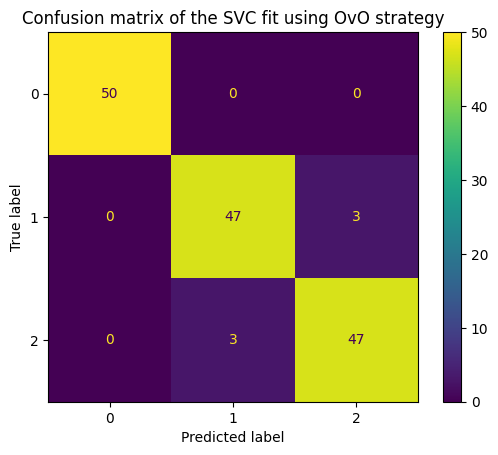

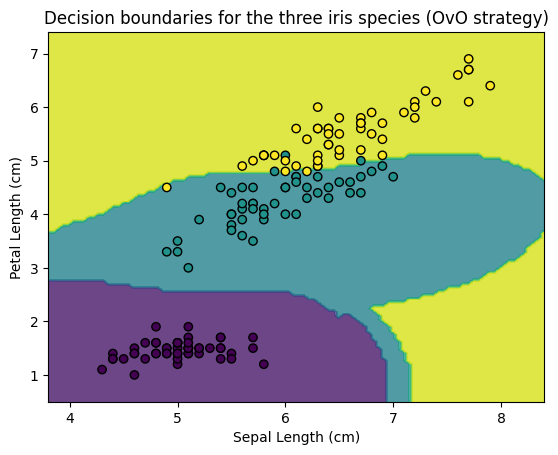

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.94      0.94      0.94        50
   virginica       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [3]:
# creating a classifier and fitting it
svm_ovo = OneVsOneClassifier(make_pipeline(StandardScaler(), SVC())).fit(X,y) 

# evaluating the classifier
print(f"accuracy = {svm_ovo.score(X, y)}")
print()

# showing the confusion matrix
print('Confusion Matrix')
y_pred = svm_ovo.predict(X)
print(confusion_matrix(y, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot()
plt.title("Confusion matrix of the SVC fit using OvO strategy")

# showing the decision boundary
DecisionBoundaryDisplay.from_estimator(svm_ovo, X, alpha=0.8, eps=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title("Decision boundaries for the three iris species (OvO strategy)")

plt.show()

print(classification_report(y, y_pred, target_names=iris_target_names))

## Fit an SVM with OvR strategy

accuracy = 0.96

Confusion Matrix
[[50  0  0]
 [ 0 48  2]
 [ 0  4 46]]


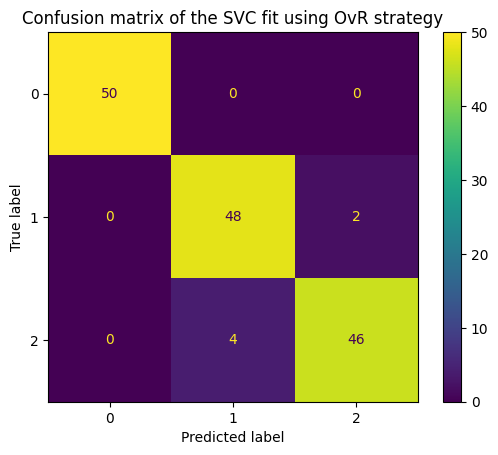

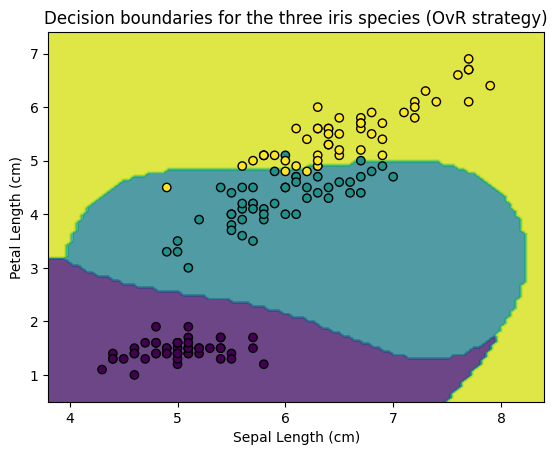

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.96      0.94        50
   virginica       0.96      0.92      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [4]:
# creating a classifier and fitting it
svm_ovr = OneVsRestClassifier(make_pipeline(StandardScaler(), SVC())).fit(X,y)

# evaluating the classifier
print(f"accuracy = {svm_ovr.score(X, y)}")
print()

# showing the confusion matrix
print('Confusion Matrix')
y_pred = svm_ovr.predict(X)
print(confusion_matrix(y, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot()
plt.title("Confusion matrix of the SVC fit using OvR strategy")

# showing the decision boundary
DecisionBoundaryDisplay.from_estimator(svm_ovr, X, alpha=0.8, eps=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title("Decision boundaries for the three iris species (OvR strategy)")

plt.show()

print(classification_report(y, y_pred, target_names=iris_target_names))

## Fit an SVM with ECOC strategy

accuracy = 0.96

Confusion Matrix
[[50  0  0]
 [ 0 48  2]
 [ 0  4 46]]


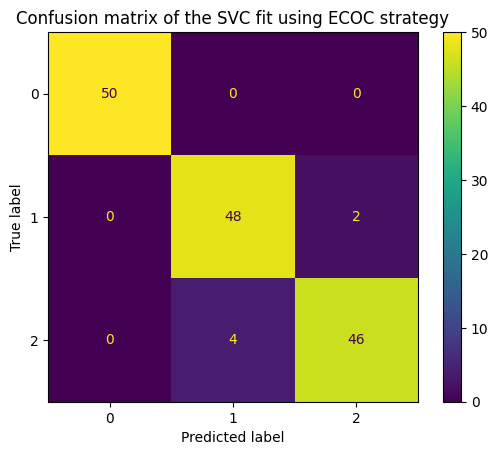

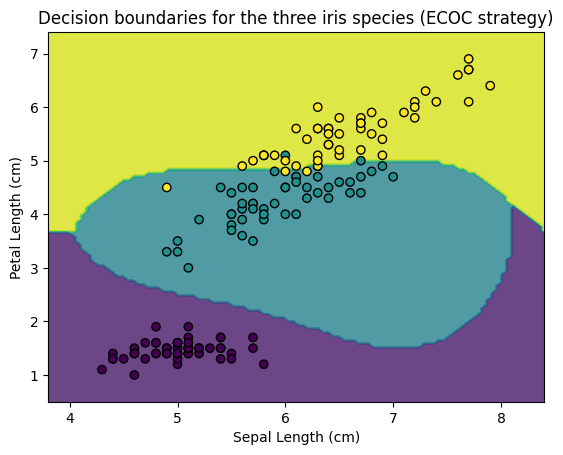

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.92      0.96      0.94        50
   virginica       0.96      0.92      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [5]:
# Code_size is the percentage of n_classes to be used as length of codeword.
# Here, we have code_size=3, hence the codewords have length 3*3 = 9.
# This means that 9 binary classifiers will be trained.
# creating a classifier and fitting it
svm_ecoc = OutputCodeClassifier(make_pipeline(StandardScaler(), SVC()),
                                code_size=3).fit(X,y)

# evaluating the classifier
print(f"accuracy = {svm_ecoc.score(X, y)}")
print()

# showing the confusion matrix
print('Confusion Matrix')
y_pred = svm_ecoc.predict(X)
print(confusion_matrix(y, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot()
plt.title("Confusion matrix of the SVC fit using ECOC strategy")

DecisionBoundaryDisplay.from_estimator(svm_ecoc, X, alpha=0.8, eps=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title("Decision boundaries for the three iris species (ECOC strategy)")
plt.show()

print(classification_report(y, y_pred, target_names=iris_target_names))